In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [22]:
df = pd.read_csv("StudentsPerformance.csv")

# Check for missing values.

In [23]:
df.isnull().mean() * 100

,0
gender,0.0
race/ethnicity,0.0
parental level of education,0.0
lunch,0.0
test preparation course,0.0
math score,0.0
reading score,0.0
writing score,0.0


# Remove duplicate records

In [24]:
df.duplicated().sum()

np.int64(0)

In [25]:
df = df.drop_duplicates()   # duplicates are absent but this will use to remove duplicates in case they are present

## Rename columns

In [26]:
df.rename(columns={"math score": "Math Score"}, inplace=True)

# Create a new column named Average_Score by calculating the average marks across all subjects.

In [27]:
df["Average_Score"] = (df["Math Score"] + df["reading score"] + df["writing score"]) / 3


In [28]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,Math Score,reading score,writing score,Average_Score
0,female,group B,bachelor's degree,standard,none,72,72,74,72.666667
1,female,group C,some college,standard,completed,69,90,88,82.333333
2,female,group B,master's degree,standard,none,90,95,93,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,49.333333
4,male,group C,some college,standard,none,76,78,75,76.333333


# Create another column named Performance using the following criteria:

  
Excellent → Average Score ≥ 90
Good → Average Score between 80 and 89
Average → Average Score between 70 and 79
Needs Improvement → Average Score below 70
Save the cleaned dataset as cleaned_student_performance.csv.


In [29]:
# Hint: df.loc[row_condition, column_name] = value
# Create Performance column
df.loc[df["Average_Score"] >= 90, "Performance"] = "Excellent"

df.loc[(df["Average_Score"] >= 80) & (df["Average_Score"] < 90),"Performance"] = "Good"
df.loc[(df["Average_Score"] >= 70) & (df["Average_Score"] < 80),"Performance"] = "Average"
df.loc[df["Average_Score"] < 70,"Performance" ]= "Needs Improvement"

In [30]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,Math Score,reading score,writing score,Average_Score,Performance
0,female,group B,bachelor's degree,standard,none,72,72,74,72.666667,Average
1,female,group C,some college,standard,completed,69,90,88,82.333333,Good
2,female,group B,master's degree,standard,none,90,95,93,92.666667,Excellent
3,male,group A,associate's degree,free/reduced,none,47,57,44,49.333333,Needs Improvement
4,male,group C,some college,standard,none,76,78,75,76.333333,Average


# Save Cleaned Data

In [31]:
df.to_csv("Cleaned_student_performance.csv", index=False)

## Data Visualization

## Bar chart showing the average marks of each student.

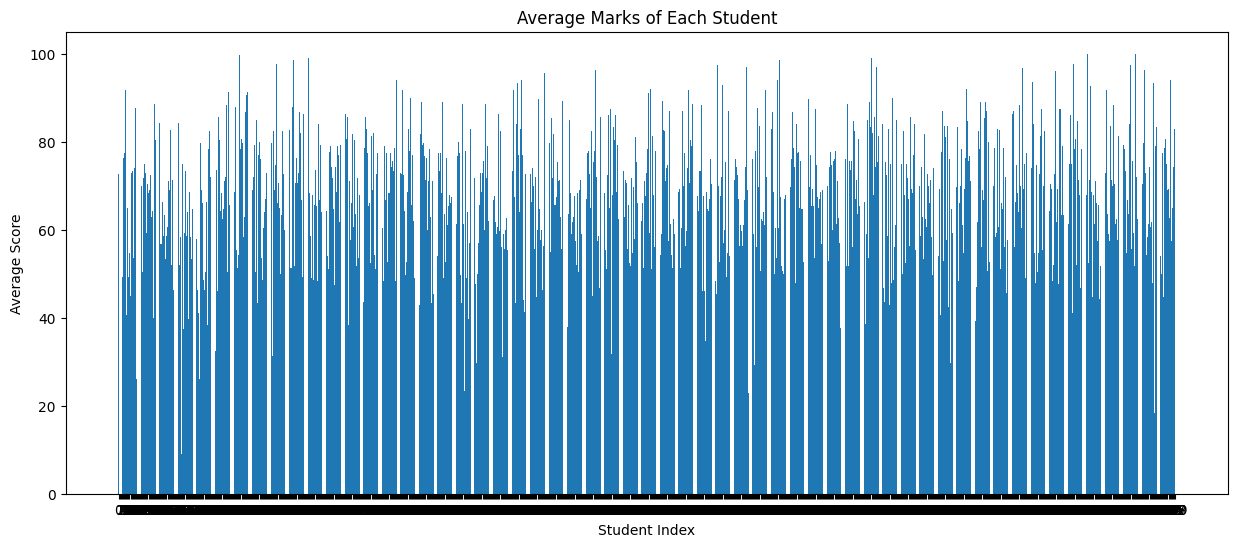

<Figure size 640x480 with 0 Axes>

In [32]:
plt.figure(figsize=(15,6))

plt.bar(
    df.index.astype(str),
    df["Average_Score"]
)

plt.title("Average Marks of Each Student")
plt.xlabel("Student Index")
plt.ylabel("Average Score")

plt.show()
plt.savefig("bar chart of average per student.png", dpi=300, bbox_inches="tight")

# Histogram showing the distribution of Average Scores.

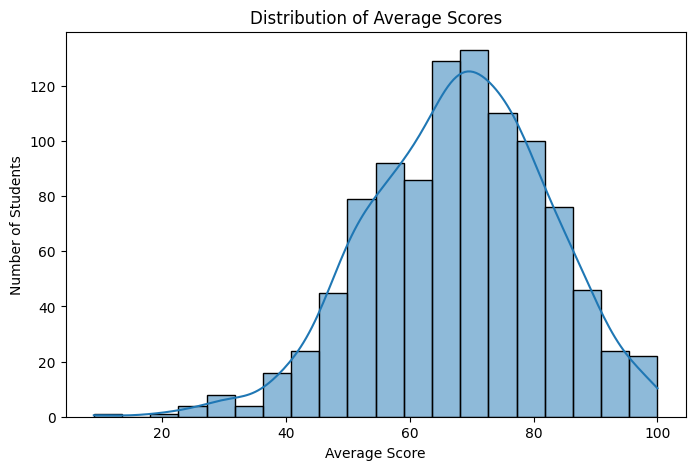

<Figure size 640x480 with 0 Axes>

In [33]:
plt.figure(figsize=(8,5))

sns.histplot(df["Average_Score"], bins=20, kde=True)

plt.title("Distribution of Average Scores")
plt.xlabel("Average Score")
plt.ylabel("Number of Students")

plt.show()
plt.savefig("historgram of distribution.png", dpi=300, bbox_inches="tight")

# Scatter plot comparing Python and Machine Learning marks.

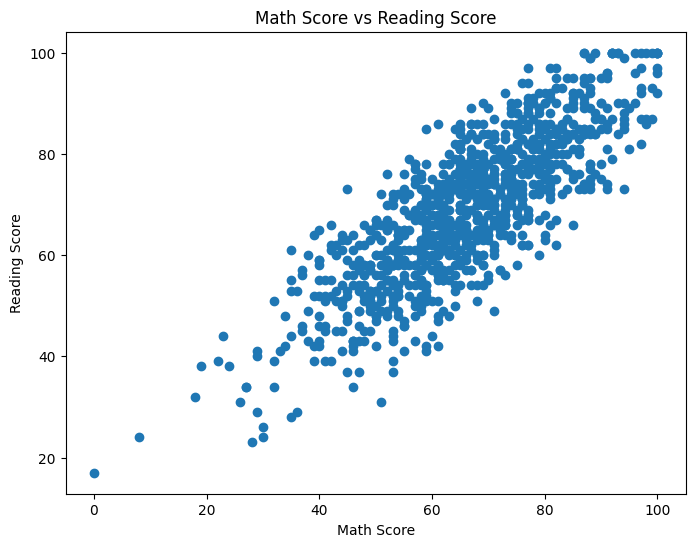

<Figure size 640x480 with 0 Axes>

In [34]:
plt.figure(figsize=(8,6))

plt.scatter(
    df["Math Score"],
    df["reading score"]
)

plt.title("Math Score vs Reading Score")
plt.xlabel("Math Score")
plt.ylabel("Reading Score")

plt.show()
plt.savefig("Scatter plot.png", dpi=300, bbox_inches="tight")

# Pie Chart Showing the Distribution of Students by Performance Category

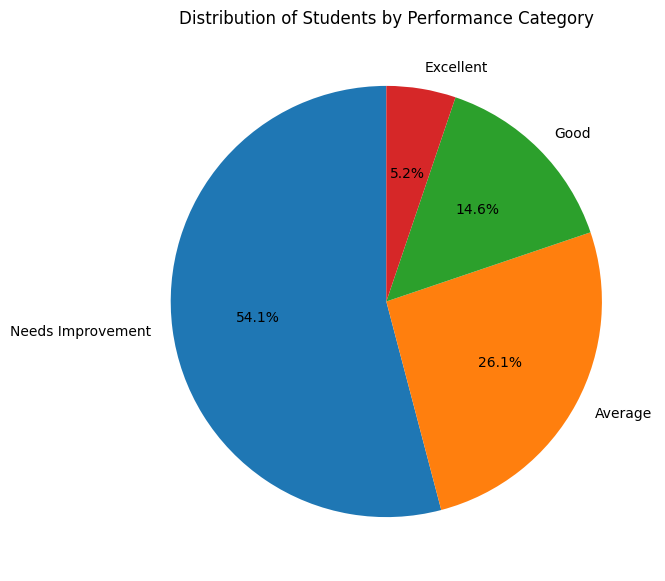

<Figure size 640x480 with 0 Axes>

In [35]:
performance = df["Performance"].value_counts()

plt.figure(figsize=(7,7))

plt.pie(
    performance,
    labels=performance.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Distribution of Students by Performance Category")

plt.show()
plt.savefig("pie_plot.png", dpi=300, bbox_inches="tight")

# Box Plot to Visualize the Spread of Marks in All Subjects

/tmp/ipykernel_14901/1179860118.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([


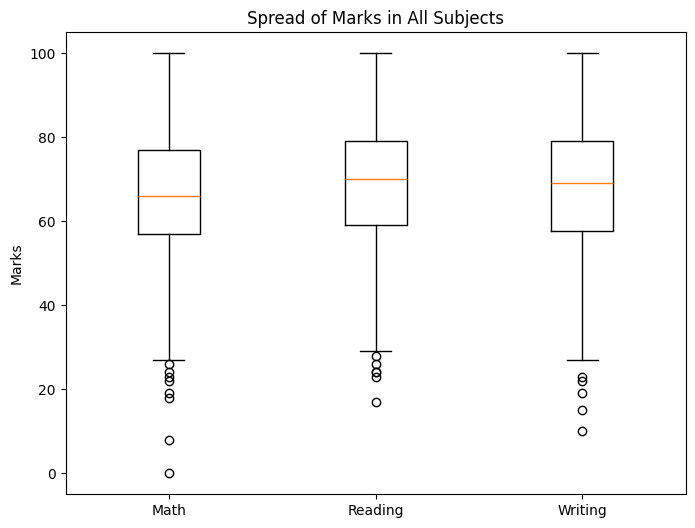

<Figure size 640x480 with 0 Axes>

In [36]:
plt.figure(figsize=(8,6))

plt.boxplot([
    df["Math Score"],
    df["reading score"],
    df["writing score"]
],
labels=["Math", "Reading", "Writing"])

plt.title("Spread of Marks in All Subjects")
plt.ylabel("Marks")

plt.show()
plt.savefig("box_plot.png", dpi=300, bbox_inches="tight")